In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load dirty dataset
df = pd.read_csv('tech_layoffs_dirtydata.csv')

print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Total duplicates: {df.duplicated().sum()}")

print("\n" + "=" * 50)
print("INVALID VALUES")
print("=" * 50)
print(f"Negative layoffs: {(df['layoffs_count'] < 0).sum()}")
print(f"Invalid percentages (>100): {(df['layoff_percentage'] > 100).sum()}")

print("\n" + "=" * 50)
print("INCONSISTENT TEXT VALUES")
print("=" * 50)
print("Industry unique values:", df['industry'].unique())
print("Hiring trend unique values:", df['hiring_trend'].unique())

print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(df.describe())

DATASET SHAPE
Rows: 12300, Columns: 23

COLUMN NAMES AND DATA TYPES
record_id                  object
company_name               object
industry                   object
country                    object
company_size               object
month                      object
year                        int64
layoffs_count             float64
layoff_percentage         float64
reason_for_layoffs         object
ai_automation_impact      float64
ai_replacement_risk       float64
open_roles                  int64
hiring_trend               object
remote_jobs_percentage    float64
top_hiring_role            object
stock_growth_percent      float64
revenue_growth_percent    float64
salary_budget_change      float64
ai_adoption_level         float64
employee_sentiment        float64
job_security_score        float64
market_condition           object
dtype: object

FIRST 5 ROWS
  record_id company_name       industry    country company_size month  year  \
0        T0    Microsoft             AI  Si

In [8]:
# DATA CLEANING
# Dataset: Tech Layoffs Dirty Data
# Purpose: Clean and prepare data for analysis

print("BEFORE CLEANING:")
print(f"Shape: {df.shape}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# Step 1 - Remove duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"\nStep 1 - Duplicates removed: {before - len(df)}")

# Step 2 - Remove invalid layoff percentage values
before = len(df)
df = df[df['layoff_percentage'] <= 100]
print(f"Step 2 - Invalid percentages removed: {before - len(df)}")

# Step 3 - Remove negative layoff counts
before = len(df)
df = df[df['layoffs_count'] >= 0]
print(f"Step 3 - Negative layoffs removed: {before - len(df)}")

# Step 4 - Fill missing numeric values with median/mean
df['layoffs_count'] = df['layoffs_count'].fillna(df['layoffs_count'].median())
df['layoff_percentage'] = df['layoff_percentage'].fillna(df['layoff_percentage'].median())
df['ai_automation_impact'] = df['ai_automation_impact'].fillna(df['ai_automation_impact'].mean())
df['salary_budget_change'] = df['salary_budget_change'].fillna(df['salary_budget_change'].mean())
print(f"Step 4 - Missing values filled with median/mean")

# Step 5 - Standardise inconsistent text formatting
df['industry'] = df['industry'].str.strip().str.title()
df['country'] = df['country'].str.strip().str.title()
df['hiring_trend'] = df['hiring_trend'].str.strip().str.title()
df['company_name'] = df['company_name'].str.strip().str.title()
print(f"Step 5 - Text columns standardised")

# Step 6 - Create new useful columns for analysis
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
             'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
df['month_num'] = df['month'].map(month_map)
df['date'] = pd.to_datetime(
    df[['year','month_num']].rename(
        columns={'year':'year','month_num':'month'}
    ).assign(day=1))
df['layoff_severity'] = pd.cut(
    df['layoff_percentage'],
    bins=[0, 2, 5, 10, 100],
    labels=['Low', 'Medium', 'High', 'Critical'])
print(f"Step 6 - New columns added: date, layoff_severity")

# Save cleaned dataset
df.to_csv('tech_layoffs_cleaned.csv', index=False)

print(f"\nAFTER CLEANING:")
print(f"Shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Duplicates remaining: {df.duplicated().sum()}")
print("Cleaned dataset saved as tech_layoffs_cleaned.csv")

BEFORE CLEANING:
Shape: (12300, 23)
Duplicates: 268
Missing values:
layoffs_count           894
layoff_percentage       608
ai_automation_impact    614
salary_budget_change    619
dtype: int64

Step 1 - Duplicates removed: 268
Step 2 - Invalid percentages removed: 745
Step 3 - Negative layoffs removed: 660
Step 4 - Missing values filled with median/mean
Step 5 - Text columns standardised
Step 6 - New columns added: date, layoff_severity

AFTER CLEANING:
Shape: (10627, 26)
Missing values remaining: 19
Duplicates remaining: 0
Cleaned dataset saved as tech_layoffs_cleaned.csv


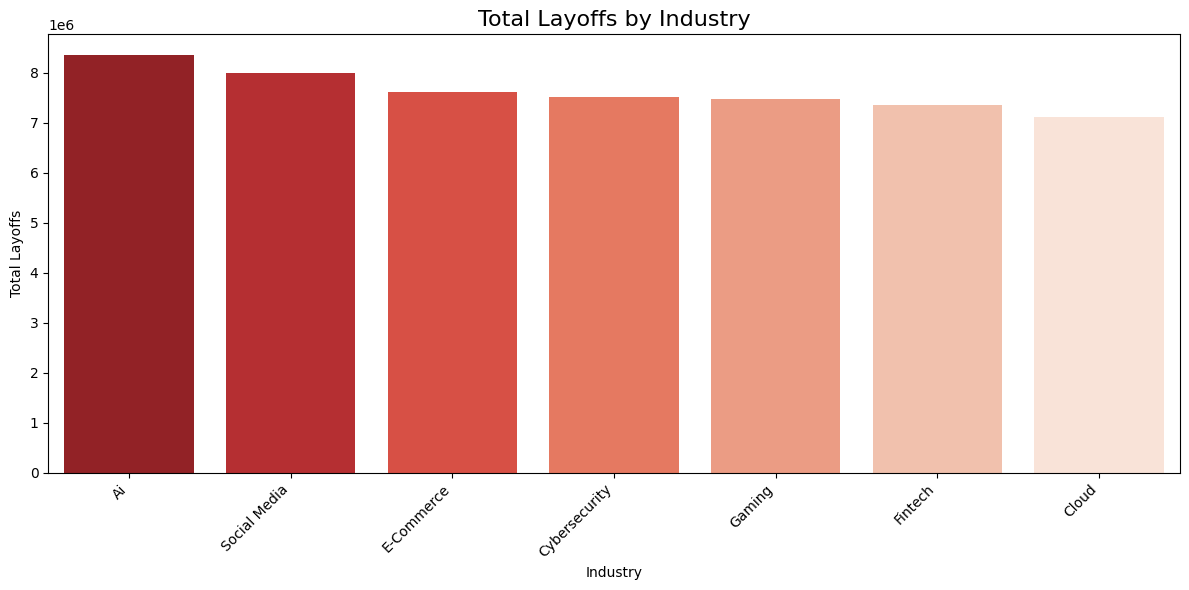

Chart saved!


In [9]:
# LAYOFFS BY INDUSTRY

plt.figure(figsize=(12, 6))
industry_layoffs = df.groupby('industry')['layoffs_count'].sum().sort_values(ascending=False)
sns.barplot(x=industry_layoffs.index, y=industry_layoffs.values, palette='Reds_r')
plt.title('Total Layoffs by Industry', fontsize=16)
plt.xlabel('Industry')
plt.ylabel('Total Layoffs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('layoffs_by_industry.png', dpi=150)
plt.show()
print("Chart saved!")

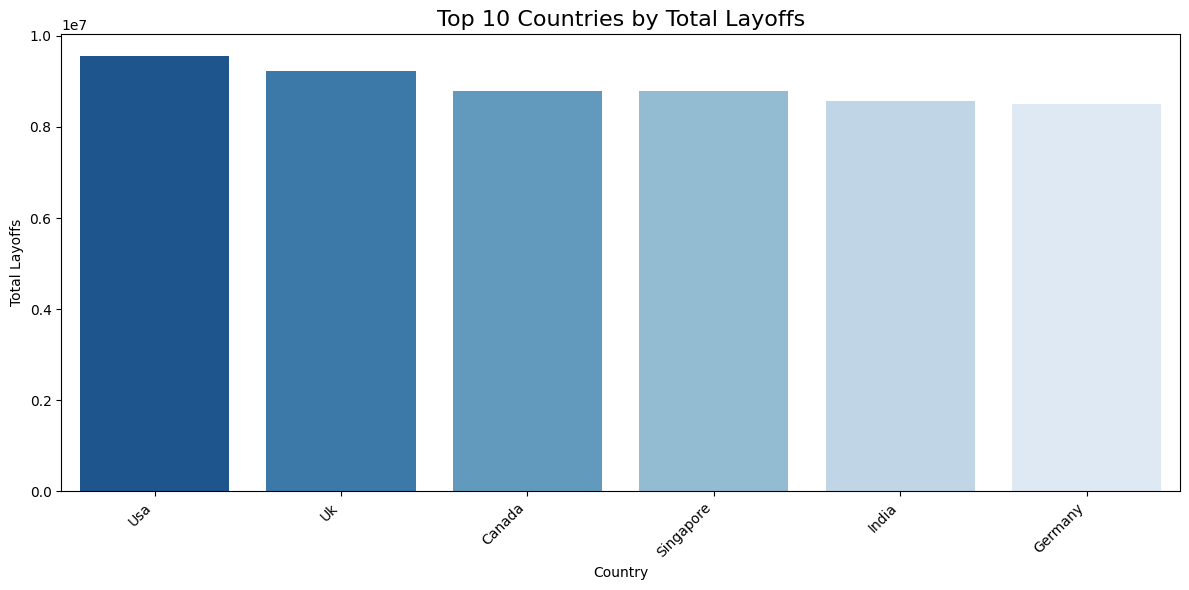

Chart saved!


In [ ]:
# LAYOFFS BY COUNTRY

plt.figure(figsize=(12, 6))
country_layoffs = df.groupby('country')['layoffs_count'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_layoffs.index, y=country_layoffs.values, palette='Blues_r')
plt.title('Top 10 Countries by Total Layoffs', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Total Layoffs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('layoffs_by_country.png', dpi=150)
plt.show()
print("Chart saved!")

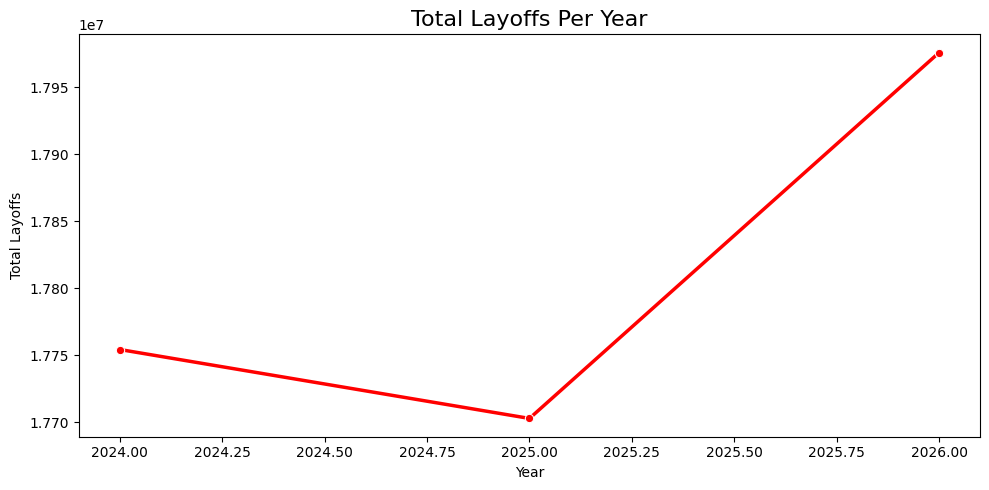

Chart saved!


In [12]:
# LAYOFFS BY YEAR

plt.figure(figsize=(10, 5))
year_layoffs = df.groupby('year')['layoffs_count'].sum()
sns.lineplot(x=year_layoffs.index, y=year_layoffs.values, marker='o', color='red', linewidth=2.5)
plt.title('Total Layoffs Per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total Layoffs')
plt.tight_layout()
plt.savefig('layoffs_by_year.png', dpi=150)
plt.show()
print("Chart saved!")

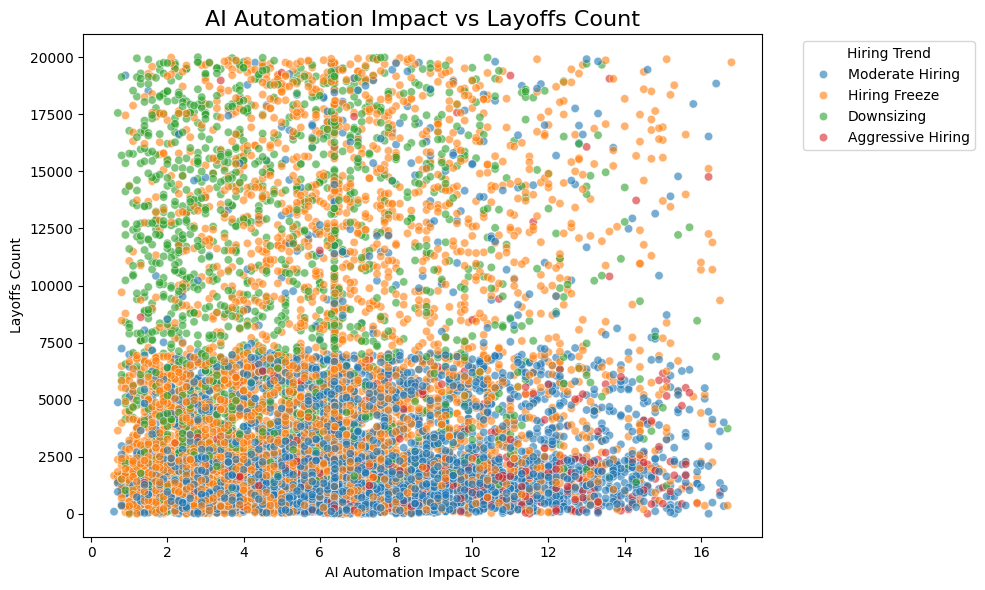

Chart saved!


In [13]:
# AI AUTOMATION IMPACT VS LAYOFFS

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ai_automation_impact', y='layoffs_count', 
                hue='hiring_trend', alpha=0.6)
plt.title('AI Automation Impact vs Layoffs Count', fontsize=16)
plt.xlabel('AI Automation Impact Score')
plt.ylabel('Layoffs Count')
plt.legend(title='Hiring Trend', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('ai_vs_layoffs.png', dpi=150)
plt.show()
print("Chart saved!")

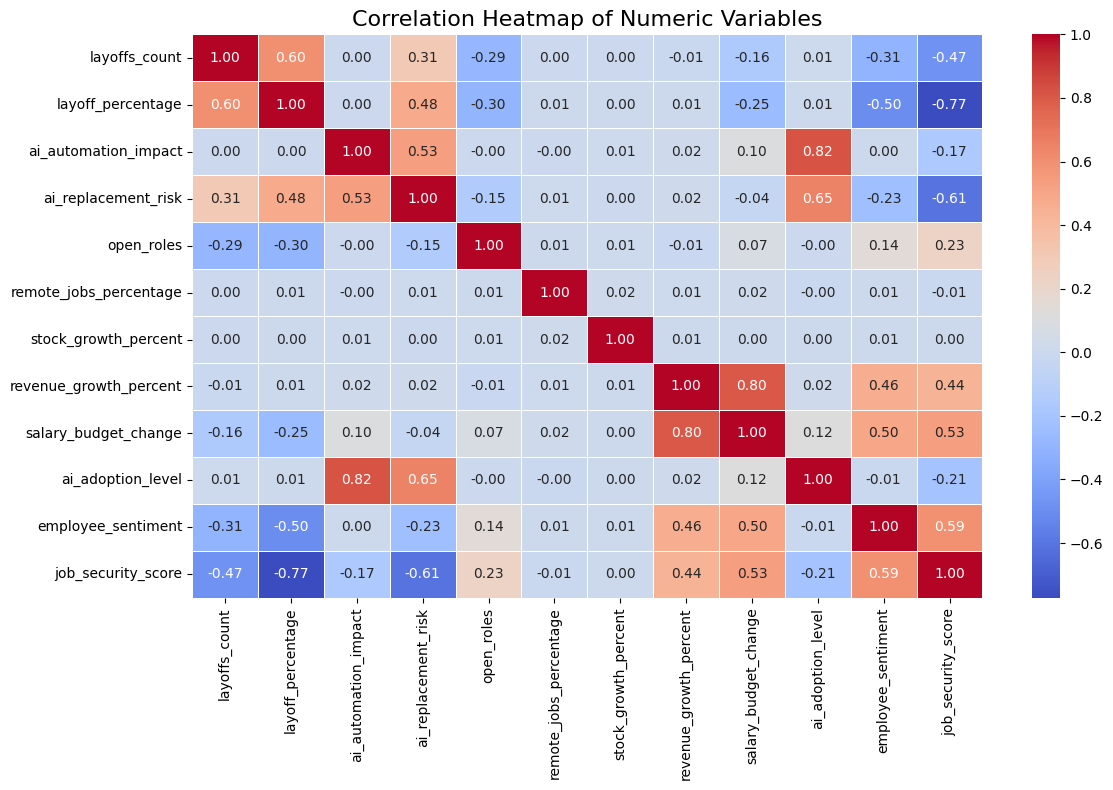

Chart saved!


In [14]:
# CORRELATION HEATMAP

plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include='number').drop(columns=['year', 'month_num'])
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Chart saved!")

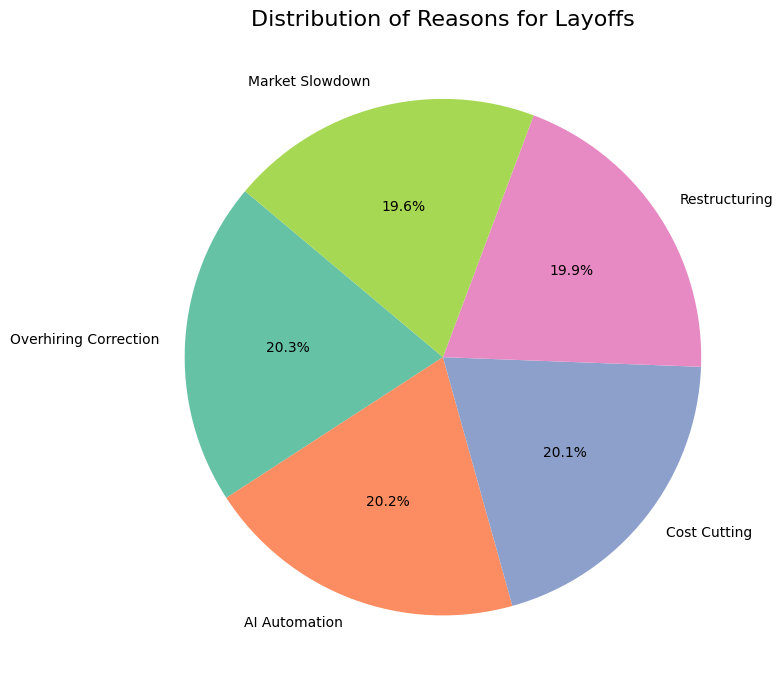

Chart saved!


In [15]:
# REASONS FOR LAYOFFS

plt.figure(figsize=(10, 7))
reasons = df['reason_for_layoffs'].value_counts()
plt.pie(reasons.values, labels=reasons.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('Set2'))
plt.title('Distribution of Reasons for Layoffs', fontsize=16)
plt.tight_layout()
plt.savefig('layoff_reasons.png', dpi=150)
plt.show()
print("Chart saved!")

Importing plotly failed. Interactive plots will not work.
21:28:53 - cmdstanpy - INFO - Chain [1] start processing
21:28:53 - cmdstanpy - INFO - Chain [1] done processing


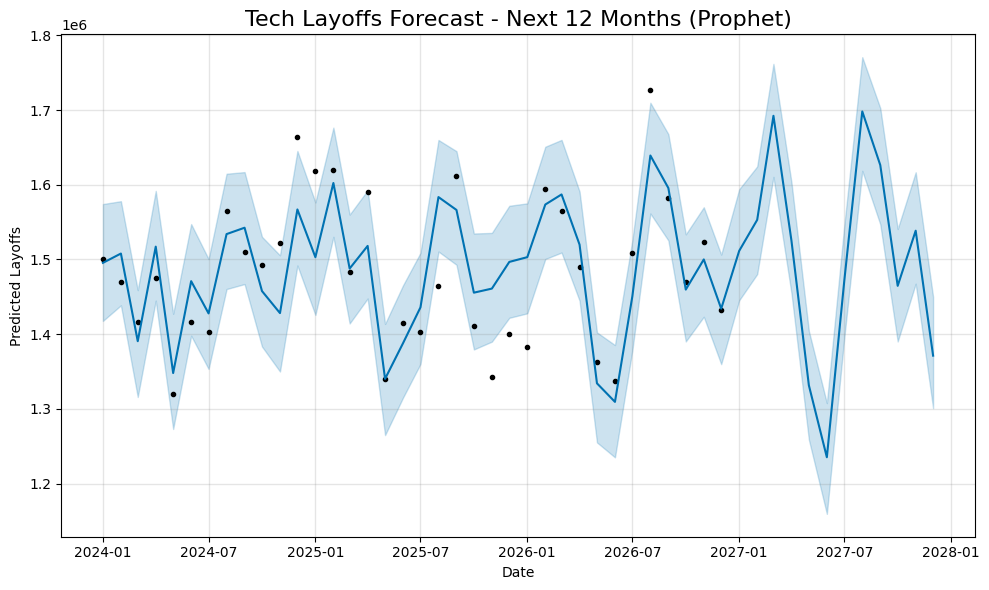

Forecast complete!


In [16]:
# CELL 9 - PROPHET ML FORECASTING

from prophet import Prophet

# Prepare data for Prophet
monthly = df.groupby(['year', 'month'])['layoffs_count'].sum().reset_index()
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
             'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
monthly['month_num'] = monthly['month'].map(month_map)
monthly['ds'] = pd.to_datetime(
    monthly[['year','month_num']].rename(
        columns={'year':'year','month_num':'month'}
    ).assign(day=1))
monthly = monthly.rename(columns={'layoffs_count':'y'})
prophet_df = monthly[['ds','y']].sort_values('ds')

# Train Prophet model
model = Prophet(yearly_seasonality=True, 
                weekly_seasonality=False, 
                daily_seasonality=False)
model.fit(prophet_df)

# Forecast next 12 months
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title('Tech Layoffs Forecast - Next 12 Months (Prophet)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Predicted Layoffs')
plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=150)
plt.show()
print("Forecast complete!")